cycle 1
33.88634657116912
3.134737568861407
['CCl4' 'O3' 'CS2' 'CH4' 'SO2' 'CF3CN' 'isobutane' 'C3H9N' 'trans-butane'
 'HCF3']
cycle 1
dft_ele 0.19315700568914362
scf_ele 0.17299204224846598
dft_dip 0.01900420140467115
scf_dip 0.03573614146218856

cycle 2
33.88631295763772
2.565621550293245
['CCl4' 'HCF3' 'CF3CN' 'PF3' 'CF4' 'C2F4' 'H2CF2' 'SO2' 'NO2' 'N2O']
cycle 2
dft_ele 0.1931571533829689
scf_ele 0.2822304141402583
dft_dip 0.019004217644620916
scf_dip 0.033088583275128175

cycle 3
33.88630828011324
9.07226710055437
['CCl4' 'C6H6' 'C4H4NH' 'C5H8' 'C5H5N' 'trans-butane' 'cyclobutane'
 'methylenecyclopropane' 'bicyclobutane' '2-butyne']
cycle 3
dft_ele 0.1931571470825831
scf_ele 0.17769508435872636
dft_dip 0.01900419436247897
scf_dip 0.026774269323856164

cycle 4
33.88638852186631
4.702606546784274
['CCl4' 'isobutane' 'C3H9N' 'trans-butane' 'C3H9C' 'C2H6CHOH' 'C3H7Cl'
 'CH3CH2OCH3' 'isobutene' 'cyclobutane']
cycle 4
dft_ele 0.19315665529940404
scf_ele 0.15985902261229648
dft_dip 0.019

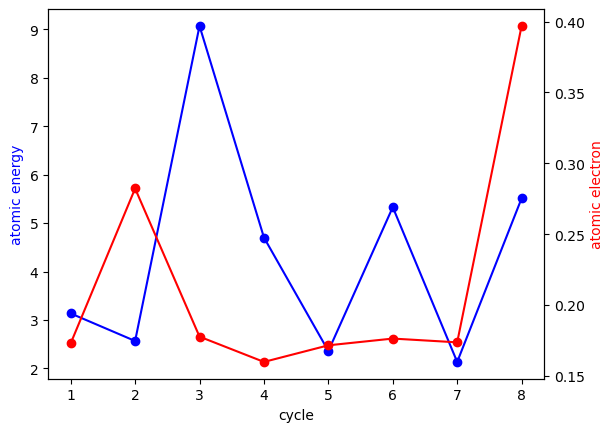

In [2]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open("../cc2cc/utils/g2.json") as f:
    json_data = json.load(f)

max_cycle = 8

data = pd.read_csv(f"../validate/ccdft_cycle{max_cycle}_g2.csv")
len_data = len(data)
data_atomic_energy_ai_save = []
data_atomic_scf_ele_save = []

for i_cycle in range(max_cycle):
    data = pd.read_csv(f"../validate/ccdft_cycle{i_cycle+1}_g2.csv")

    data = data[:len_data]

    data["name"] = data["name"].str.split("_cc").str[0]
    data_atomic_energy_dft = []
    data_atomic_energy_ai = []
    data_atomic_dft_ele = []
    data_atomic_scf_ele = []
    data_atomic_dft_dip = []
    data_atomic_scf_dip = []

    for i_name in data["name"]:
        systems_list = json_data["reaction-atomic-energy"][i_name]["systems"]
        stoichiometry_list = json_data["reaction-atomic-energy"][i_name][
            "stoichiometry"
        ]

        atomic_energy_dft = 0
        atomic_energy_ai = 0
        for i in range(len(systems_list)):
            atomic_energy_dft += data[data["name"] == systems_list[i]][
                "error_dft_ene"
            ].values[0] * int(stoichiometry_list[i])
            atomic_energy_ai += data[data["name"] == systems_list[i]][
                "error_scf_ene"
            ].values[0] * int(stoichiometry_list[i])
        data_atomic_energy_dft.append(atomic_energy_dft)
        data_atomic_energy_ai.append(atomic_energy_ai)

        data_atomic_dft_ele.append(
            data.loc[data["name"] == i_name, "error_dft_ele"].values[0]
        )
        data_atomic_scf_ele.append(
            data.loc[data["name"] == i_name, "error_scf_ele"].values[0]
        )
        data_atomic_dft_dip.append(
            data.loc[data["name"] == i_name, "error_dft_dip"].values[0]
        )
        data_atomic_scf_dip.append(
            data.loc[data["name"] == i_name, "error_scf_dip"].values[0]
        )

    print(f"cycle {i_cycle+1}")
    print(np.mean(np.abs(data_atomic_energy_dft)))
    print(np.mean(np.abs(data_atomic_energy_ai)))
    sorted_indices = np.argsort(np.abs(data_atomic_energy_ai))[::-1][:10]
    sorted_data_atomic_energy_ai = np.array(data["name"])[sorted_indices]
    print(sorted_data_atomic_energy_ai)

    print(f"cycle {i_cycle+1}")
    print("dft_ele", np.mean(np.abs(data_atomic_dft_ele)))
    print("scf_ele", np.mean(np.abs(data_atomic_scf_ele)))
    print("dft_dip", np.mean(np.abs(data_atomic_dft_dip)))
    print("scf_dip", np.mean(np.abs(data_atomic_scf_dip)))

    data_atomic_energy_ai_save.append(np.mean(np.abs(data_atomic_energy_ai)))
    data_atomic_scf_ele_save.append(np.mean(np.abs(data_atomic_scf_ele)))
    print()

# matplotlib in dual axis, left is atomic energy, right is atomic dipole
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.set_xlabel("cycle")
ax1.set_ylabel("atomic energy", color="b")
ax2.set_ylabel("atomic electron", color="r")
ax1.plot(
    range(1, max_cycle + 1),
    data_atomic_energy_ai_save,
    ls="-",
    marker="o",
    c="b",
)
ax2.plot(
    range(1, max_cycle + 1),
    data_atomic_scf_ele_save,
    ls="-",
    marker="o",
    c="r",
)

In [12]:
ax1.plot(
    range(1, max_cycle + 1),
    data_atomic_energy_ai_save,
    ls="-",
    marker="o",
    c="b",
)
ax2.plot(
    range(1, max_cycle + 1),
    data_atomic_scf_ele_save,
    ls="-",
    c="r",
)
plt.show()